In [1]:
# 15 March 2025
# Zachary Katz
# zachary_katz@mines.edu

"""
Specularity example, showcasing reflections from both the lake and bed at once!
"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import segyio

%matplotlib inline

### MANUALLY SELECTED PARAMETERS ###
win_m = 750.0 # window length [m]
ovlp_m = 250.0 # overlap [m]

In [2]:
# Set paths and make output directory
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
lake_path = '../_Data/Ju_SLD2'
seismic_path = '../_Data/Ju_Seismic/SeismicKSS2_21-22.csv'
seismic_sgy = '../_Data/Ju_Seismic/D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy'
outdir = '.'
os.makedirs(outdir, exist_ok=True)

# Helper functions
def compute_doppler_spectrum(radargram, start_x,end_x):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    # Example coordinates at the bed
    start_y = 1100
    end_y = 1800

    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]

    x_center = np.mean(x_at[start_x:end_x])
    y_center = np.mean(y_at[start_x:end_x])

    # Get low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    
    # Hilbert along fast_time axis
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Fast fourier transform
    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make frequency axis
    t = radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y, x_center, y_center

def calc_doppler_ridge(freq, data_fft, start_y, end_y):
    """Use a Sato filter to extract the main band of a doppler spectrum.

    Parameters
    ----------
    freq : numpy.ndarray
        Frequency axis values of Fourier transform
    data_fft : numpy.ndarray
        2D fourier transform output
    start_y : float
        Starting y value of Fourier transform
    end_y : float
        Ending y value of Fourier transform

    Returns
    -------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    rad_db_sato : numpy.ndarray
        Sato-filtered and masked spectrum
    """

    # Transform radargram to log scale
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Filter for main band of spectrum and mask
    rad_db = scipy.ndimage.gaussian_filter(rad_db, sigma=(3,2))
    rad_db = skimage.filters.sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (skimage.filters.threshold_otsu(rad_db))
    rad_db_sato = rad_db * mask

    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    return x, start_y + max_indices, rad_db_sato

def calc_width_and_max(x,y,threshold):
    """
    Find width and max of Sato-filtered doppler spectra.
    Start with y location of middle point, assumed to be in the main parabola 
    [valid unless severely sloping]. Work out in both directions until distance
    between point and prior point is greater than a threshold

    Parameters
    ----------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    threshold : float
        Gap tolerance in algorithm [ns]

    Returns
    -------
    x[right] : float
        Right edge x-value
    x[left] : float
        Left edge x-value
    x_at_max : float
        x-value at maximum y
    y_at_max : float
        Maximum y-value
    """

    y = -y # Flip direction convention (Depth increases downward)
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find right edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index < len(y)-1):
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Find left edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index > 0):
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    
    # Return nan if no max found
    try:
        y_at_max = -np.max(y_masked)
        x_at_max = x[np.argmax(y_masked) + left]
    except:
        y_at_max = np.nan
        x_at_max = np.nan

    return x[right],x[left], x_at_max, y_at_max

def plot_doppler(freq, data_fft, start_y, end_y, ridge_params, rad_db_sato):
    """
    Plot doppler spectrum and Sato-filtered doppler spectrum with max and width
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Get doppler spectrum in dB
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Plot doppler spectrum
    im1 = ax1.imshow(rad_db, aspect='auto', cmap='gray', origin='lower', extent = [freq[0], freq[-1],start_y, end_y], vmin=-50, vmax=0)
    # Prettify ax1
    ax1.invert_yaxis()
    cb1 = fig.colorbar(im1, ax=ax1)
    ax1.set_ylabel("Fast Time [ns]",fontsize=16)
    ax1.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax1.tick_params(labelsize=14)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label("Amplitude [dB]", fontsize=16)

    # Plot Sato-filtered doppler spectrum
    im2 = ax2.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])
   
    # Scatter maximum and width
    
    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    ax2.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
    ax2.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    ax2.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)
    
    # Prettify ax2
    ax2.invert_yaxis()
    cb2 = fig.colorbar(im2, ax=ax2, label="Amplitude [dB]")
    fig.tight_layout()
    ax2.set_ylabel("Fast Time [ns]",fontsize=16)
    ax2.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax2.tick_params(labelsize=14)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label("Sato [Thresholded]", fontsize=16)

    fig.tight_layout()
    return fig


def plot_radargram_planview_width(ax, xs_lake, ys_lake, plot_dict):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plot_dict['x_centers'], plot_dict['y_centers'], plot_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label(r"Spatial Freq Width [m$^{-1}$]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    return fig

In [3]:
# Load KRT2 offset video netcdf files

file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1819[0]

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1617[0]

len(offset_video_radargrams_1819), len(offset_video_radargrams_1617)


(42, 11)

In [21]:
# Convert from spatial freq width to doppler width

MS_TO_KMHR = 3.6
for radargram in offset_video_radargrams_1819[:]:
    avg_distance = np.mean(np.diff(radargram['distance'].values))

    time = (radargram['time'][-1] - radargram['time'][0])
    time = time / np.timedelta64(1, 's')
    
    velocity = (radargram['distance'][-1] - radargram['distance'][0]).values / time #m/s
    radargram['avg_velocity']  = velocity

    dt = np.gradient(radargram.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
    dd = np.gradient(radargram.distance.values) # meters
    radargram['velocity'] = (('distance',), dd/ dt) # m/s

In [22]:
# Find radargram with transect id containing a certian Name
rad_no = 'Y26a'
for radargram in offset_video_radargrams_1819:
    if rad_no in radargram.transect_id:
        print(radargram.transect_id)
        test_rad = radargram
        break

D2DG/IBH0g/Y26a


In [23]:
x_at = test_rad['distance'].compute().values  # meters
dx = np.median(np.diff(x_at))
print("Along-track spacing:", dx, "m")

win_m = 750.0     # window length [m]
ovlp_m = 250.0     # overlap [m]
win_n = int(win_m / dx)
step_n = int((win_m - ovlp_m) / dx)
print("Window samples:", win_n)
print("Step samples:", step_n)

dt_slow = np.median(np.diff(
    (test_rad['time'] - test_rad['time'][0])
    .astype('timedelta64[ns]')
    .astype(np.float64)
    .compute()
)) * 1e-9

freq = np.fft.fftshift(
    np.fft.fftfreq(win_n, d=dt_slow)
)

from scipy.signal import hilbert
from scipy.signal.windows import hann
data = test_rad['bxds2'].compute().astype(np.float32)
# Hilbert along fast_time axis
analytic = hilbert(data, axis=1)

data = analytic.T
start_y = 1200
end_y = 1800
start_x = 15625
end_x = 20875

#start_y = 1200
#end_y = 2000
#start_x = 0
#end_x = 10000


data_for_plot = data[start_y:end_y:,start_x:end_x]
x_at = test_rad['distance'].compute().values  # meters
x_at = x_at[start_x:end_x]
data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
window = hann(win_n)

doppler_cubes = []     # list of [range, doppler]
x_centers = []         # along-track center positions

for start in range(0, data.shape[1] - win_n + 1, step_n):
    stop = start + win_n

    # Extract slow-time window
    data_win = data[:, start:stop]

    # Apply slow-time window
    data_win = data_win * window[None, :]

    # Doppler FFT
    fft_win = np.fft.fftshift(
        np.fft.fft(data_win, axis=1),
        axes=1
    )

    doppler_cubes.append(fft_win)

    # Store center along-track distance
    x_centers.append(np.mean(x_at[start:stop]))

eps = 1e-20
doppler_db = []
for cube in doppler_cubes:
    amp = np.abs(cube)  
    amp = amp / np.max(amp)
    db = 20 * np.log10(amp + eps)
    doppler_db.append(db)

n = len(doppler_db)

Along-track spacing: 1.0 m
Window samples: 750
Step samples: 500


In [30]:
# Get velocity at center of each window and make doppler freq axis
velocities = []
doppler_freqs = []
for center in x_centers:
    idx = np.argmin(np.abs(test_rad['distance'].compute().values - center))
    velocities.append(test_rad['velocity'][idx].values)

# Doppler freq axis, one for each velocity 
doppler_freqs = [freq * velocity  for velocity in velocities]

In [6]:
# Set up plan view plotting function
def plot_radargram_planview(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for radargram in radargrams[:]:
        ax.plot(radargram.x, radargram.y, color='gainsboro', zorder=3, transform=ps71_projection,linewidth=1,alpha=0.7)
        #print(radargram.transect_id.split('/')[-1])
        #if radargram.transect_id.split('/')[-1] == rad_no:
            #ax.text(radargram.x[0], radargram.y[0], radargram.transect_id.split('/')[-1], color='red', fontsize=15, transform=ps71_projection, zorder=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='black', linewidth=1, zorder=0, alpha=0.8)
    ax.scatter(seismic['Shot_X'], seismic['Shot_Y'], s=1, c='cyan', label='Seismic Shots', transform=ps71_projection)
    # Add color where X26a from 10000m to 15000m along track
    msk = (test_rad['distance'] >= start_x) & (test_rad['distance'] <= end_x)
    rad_color = ax.scatter(test_rad['x'].where(msk), test_rad['y'].where(msk), c=test_rad['distance'], cmap='plasma', zorder=4, transform=ps71_projection,vmin=start_x,vmax=end_x, s=1)


    return rad_color

In [7]:
import pandas as pd
from pyproj import CRS, Transformer

def ll2xy(lon: list[float], lat: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y).
    Can also take single floats.

    Parameters
    ----------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326

    Returns
    -------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y

seismic = pd.read_csv(seismic_path)
seismic['x'], seismic['y'] = ll2xy(seismic['LONGITUDE'], seismic['LATITUDE'])



In [8]:
# Load Subglacial Lake Cheongsuk shapefile
pathA = lake_path + '/SLD2-A.shp'
pathB = lake_path + '/SLD2-B.shp'
pathC = lake_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


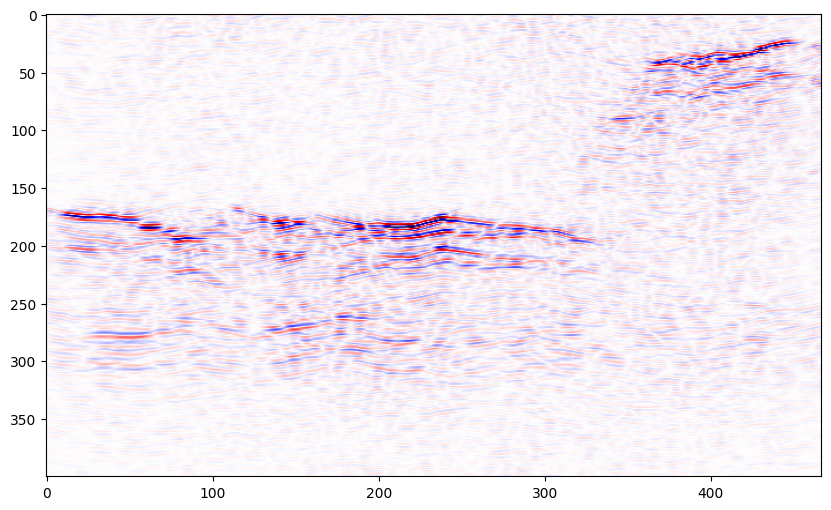

In [10]:
with segyio.open(seismic_sgy, "r", ignore_geometry=True) as f:
    n_traces = f.tracecount     
    n_samples = f.samples.size  

    data = np.empty((n_traces, n_samples), dtype=np.float32)

    # Copy each trace into the array
    for i in range(n_traces):
        data[i, :] = f.trace[i]

cropped_seismic = data[:, 1000:1400]

plt.figure(figsize=(10,6))
plt.imshow(
    cropped_seismic.T,   
    cmap='seismic',
    aspect='auto',
    origin='upper',
    vmin=-100, vmax=100
)

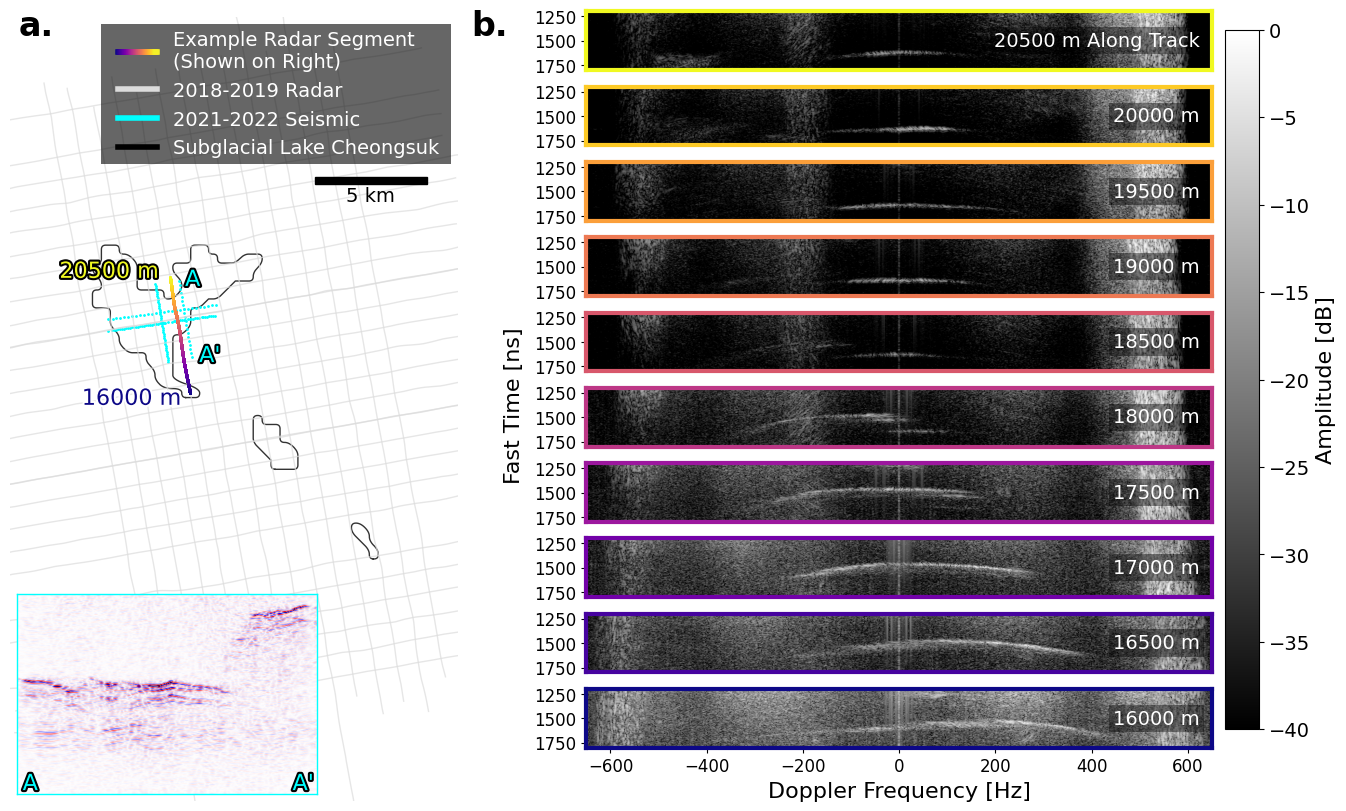

In [34]:
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4], figure=fig)

ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
ax_map = fig.add_subplot(gs[0], projection=ps71_projection)

rad_color = plot_radargram_planview(ax_map, offset_video_radargrams_1819, xs_lake, ys_lake)

scalebar = AnchoredSizeBar(ax_map.transData, 5000, '5 km', 'lower right', pad=1.5, color='black', frameon=False, size_vertical=300, fontproperties={'size': 14})
ax_map.add_artist(scalebar)
scalebar.set_bbox_to_anchor((1, 0.72), transform=ax_map.transAxes)

###### RIGHT SIDE ####
gs_right = gs[1].subgridspec(n, 1, hspace=-0.5)
axes = []
axes.append(fig.add_subplot(gs_right[0]))  # first axis

for i in range(1, n):
    axes.append(fig.add_subplot(gs_right[i], sharex=axes[0]))

box_outlines = plt.get_cmap('plasma', len(axes))

for i, ax in enumerate(axes):
    im = ax.imshow(
        doppler_db[len(axes) - i - 1],
        aspect='auto',
        origin='lower',
        extent = [ doppler_freqs[len(axes) - i - 1][0], doppler_freqs[len(axes) - i - 1][-1],start_y, end_y],
        cmap='gray',
        vmin=-40, vmax=0,
        
    )
    color = box_outlines(len(axes) - i - 1)

    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(3)

    ax.invert_yaxis()
    #ax.set_ylabel("Fast Time [ns]", fontsize=14)
    ax.tick_params(labelsize=12)

    ax.set_xlim(-650,650)

    # Top-right panel title
    if i == 0:
        ax.text(
            0.98, 0.5,
            f"{x_centers[len(axes) - i - 1]:.0f} m Along Track",
            transform=ax.transAxes,
            ha="right",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
        )
    else:
        ax.text(
            0.98, 0.5,
            f"{x_centers[len(axes) - i - 1]:.0f} m",
            transform=ax.transAxes,
            ha="right",
            va="center",
            fontsize=14,
            color="white",
            bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
        )

# X label only on bottom panel
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)   # hide x tick labels
    # Remove ticks
    ax.tick_params(axis='x', which='both', length=0)
axes[-1].set_xlabel("Doppler Frequency [Hz]", fontsize=16)

# Single shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    pad=0.02,
    shrink=0.95
)
cbar.set_label("Amplitude [dB]", fontsize=16)
cbar.ax.tick_params(labelsize=14)
# position just left of Doppler stack
fig.text(0.41, 0.5, "Fast Time [ns]",
         rotation=90,
         va='center',
         ha='center',
         fontsize=16)


k_cbar_anchor = (1,1) # Bottom right of ax1
cbbox = inset_axes(ax_map, width=3.5,height=1.4,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax_map.transAxes, loc="upper right")
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
cbbox.set_facecolor([0,0,0,0.6])

# Multicolor legend line adapted from SAUTHOFF ET AL., 2026
#https://github.com/wsauthoff/Sauthoff-2025-GRL/blob/main/FigS1_lake_reexamination_methods.ipynb
dummy = []
# Make cmap from range 1 to 100
mgma = plt.get_cmap('plasma', 100)
for i in range(100):
    line, = ax.plot([], [], color=mgma(i), lw=4)  
    dummy.append(line)
    
handles = [
    tuple(dummy),
    Line2D([0], [0], color='gainsboro', lw=4, label='2019-2019 Radar'),
    Line2D([0], [0], color='cyan', lw=4, label='2021-2022 Seismic'),
    Line2D([0], [0], color='black', lw=4, label='Subglacial Lake Cheongsuk'),
]

# Add legend directly to cbbox
legend = cbbox.legend(
    handles=handles,
    labels = [
        "Example Radar Segment\n(Shown on Right)",
        "2018-2019 Radar",
        "2021-2022 Seismic",
        "Subglacial Lake Cheongsuk"
    ],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
    loc='center left',          # center vertically, left horizontally
    bbox_to_anchor=(0.0, 0.5), # tweak horizontal position
    frameon=False,
    fontsize=14,
    labelcolor='white'
)

# Make sure text is white
for text in legend.get_texts():
    text.set_color('white')

# Label radar
met_x1 = test_rad['x'].sel(distance=start_x, method='nearest').values
met_y1 = test_rad['y'].sel(distance=start_x, method='nearest').values
met_x2 = test_rad['x'].sel(distance=end_x, method='nearest').values
met_y2 = test_rad['y'].sel(distance=end_x, method='nearest').values
ax_map.text(met_x1 -400, met_y1 - 500, f'{start_x+375} m', color=mgma(0), fontsize=16, transform=ps71_projection, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax_map.text(met_x2 - 500, met_y2, f'{end_x-375} m', color=mgma(100), fontsize=16, transform=ps71_projection, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Label seismic
ax_map.text(663500,-1447000, "A", color='cyan', fontsize=16, transform=ps71_projection, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax_map.text(664400,-1450400, "A'", color='cyan', fontsize=16, transform=ps71_projection, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# INSET FOR SEISMIC

k_cbar_anchor = (0,0) # Bottom right of ax1
cbbox = inset_axes(ax_map, width=3,height=2,
                bbox_to_anchor=k_cbar_anchor,
                bbox_transform=ax_map.transAxes, loc="lower left")
[cbbox.spines[k].set_visible(True) for k in cbbox.spines]
[cbbox.spines[k].set_color('cyan') for k in cbbox.spines]
[cbbox.spines[k].set_linewidth(1) for k in cbbox.spines]
cbbox.tick_params(
    axis = 'both',
    left = False,
    top = False,
    right = False,
    bottom = False,
    labelleft = False,
    labeltop = False,
    labelright = False,
    labelbottom = False
)
clip = 100
vmin_seismic, vmax_seismic = -clip, clip
cbbox.imshow(cropped_seismic.T, cmap=plt.cm.seismic, vmin=vmin_seismic, vmax=vmax_seismic,aspect='auto', origin='upper')
cbbox.text(0.07,0.02, "A", color='cyan', fontsize=16, transform=cbbox.transAxes, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='black')])
cbbox.text(0.99,0.02, "A'", color='cyan', fontsize=16, transform=cbbox.transAxes, zorder=6,ha='right',path_effects=[pe.withStroke(linewidth=3, foreground='black')])

# Label panels
ax_map.text(0.02, 1.01, 'a.', transform=ax_map.transAxes, fontsize=24, fontweight='bold', va='top', ha='left', color='black')
ax_map.text(1.03, 1.01, 'b.', transform=ax_map.transAxes, fontsize=24, fontweight='bold', va='top', ha='left', color='black')

bbox_map = [655000,-1470000,675000,-1435000] #David_SGL2
ax_map.set_xlim(bbox_map[0], bbox_map[2])
ax_map.set_ylim(bbox_map[1], bbox_map[3])

fig.savefig('Figure3.png', dpi=300, bbox_inches='tight')